In [126]:
library(WGCNA)
# Allow multi-threading
enableWGCNAThreads()
library(DESeq2)
library(TCGAbiolinks)
library(biomaRt)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(ggplot2)
library(GEOquery)
library(miRBaseConverter)
library(sva)
library(readr)
library(dplyr)

Allowing parallel execution with up to 11 working processes.


In [127]:
# set working directory
setwd("/home/seba/github_repos/crc_weighted_network/taiwanese_cohort/count_matrices_by_geneid")

In [128]:
# Load RNA and miRNA data, ENSURE THESE COME PRE-FILTERED (remove low counts)
rna_counts <- read.csv("RNA_merged_counts_filtered.csv", row.names = 1, sep=",", header=TRUE)

mirna_counts <- read.csv("miRNA_merged_counts_filtered.csv", row.names = 1, sep=",", header=TRUE)

# Load metadata
metadata <- read.csv("all_metadata_taiwan.csv", row.names = 1, header=TRUE)
rna_metadata <- metadata[metadata$Assay.Type == "RNA-Seq", ]
mirna_metadata <- metadata[metadata$Assay.Type == "miRNA-Seq", ]

# ensure order
rna_metadata <- rna_metadata[colnames(rna_counts), ]
mirna_metadata <- mirna_metadata[colnames(mirna_counts), ]

# write also the same rna and mirna raw counts but transposed
write.csv(as.data.frame(rna_counts), file="RNA_merged_T_filtered.csv")
write.csv(as.data.frame(mirna_counts), file="miRNA_merged_T_filtered.csv")

In [129]:
# Do the differential expression analysis
dds <- DESeqDataSetFromMatrix(countData = rna_counts,
                              colData = rna_metadata,
                              design = ~ PHENOTYPE)
dds <- DESeq(dds)
res <- results(dds, contrast=c("PHENOTYPE", "neoplastic", "adjacent normal"))
res_ordered <- res[order(res$padj), ]

df_rna = res_ordered
df_rna$Category <- "Not significant" # Criteria can be changed
df_rna[which(df_rna$log2FoldChange > 1 & df_rna$padj <= 0.001),]$Category <- "Up-regulated"
df_rna[which(df_rna$log2FoldChange <= -1 & df_rna$padj <= 0.001),]$Category <- "Down-regulated"

df_rna <- df_rna[df_rna$Category != "Not significant", ]

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
 

In [130]:
# DESeq2 on mirna data now
mirna_merged_raw <- as.matrix(mirna_counts)
dds_mirna <- DESeqDataSetFromMatrix(countData = mirna_merged_raw,
                              colData = mirna_metadata,
                              design = ~ PHENOTYPE)
dds_mirna <- DESeq(dds_mirna)
res_mirna <- results(dds_mirna, contrast=c("PHENOTYPE", "neoplastic", "adjacent normal"))
res_mirna = res_mirna[order(res_mirna$padj), ]
res_mirna <- res_mirna[!is.na(res_mirna$padj), ]

res_mirna_ordered <- res_mirna[order(res_mirna$padj), ]
df_mirna = res_mirna_ordered
df_mirna$Category <- "Not significant" # Criteria can be changed
df_mirna[which(df_mirna$log2FoldChange > 1 & df_mirna$padj <= 0.001),]$Category <- "Up-regulated"
df_mirna[which(df_mirna$log2FoldChange <= -1 & df_mirna$padj <= 0.001),]$Category <- "Down-regulated"

df_mira <- df_mirna[df_mirna$Category != "Not significant", ]

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
 

In [131]:
# write rna and mirna results to tsv files
write.table(df_rna, file="DESeq2_RNA_results.tsv", sep="\t", quote=FALSE, row.names=TRUE, col.names = NA)
write.table(df_mirna, file="DESeq2_miRNA_results.tsv", sep="\t", quote=FALSE, row.names=TRUE, col.names = NA)

In [132]:
# save DESeq2 normalized counts too
norm_counts <- counts(dds, normalized=TRUE)
vsd_counts <- varianceStabilizingTransformation(dds, blind = TRUE)

norm_counts_mirna <- counts(dds_mirna, normalized=TRUE)
vsd_counts_mirna <- varianceStabilizingTransformation(dds_mirna, blind = TRUE)

#rlog_counts <- rlog(dds, blind=TRUE)
#rlog_counts_mirna <- rlog(dds_mirna, blind=TRUE)

write.csv(t(as.data.frame(norm_counts)), file="RNA_merged_T_deseq2.csv")
write.csv(t(assay(vsd_counts)), file="RNA_merged_T_vsd.csv")
#write.csv((assay(rlog_counts)), file="rna_rlog_counts.csv")

write.csv(t(as.data.frame(norm_counts_mirna)), file="miRNA_merged_T_deseq2.csv")
write.csv(t(assay(vsd_counts_mirna)), file="miRNA_merged_T_vsd.csv")
#write.csv((assay(rlog_counts_mirna)), file="mirna_rlog_counts.csv")

In [133]:
vsd <- varianceStabilizingTransformation(dds, blind = TRUE)
pca <- prcomp(t(assay(vsd)), scale. = FALSE)
percentVar <- (pca$sdev^2) / sum(pca$sdev^2)

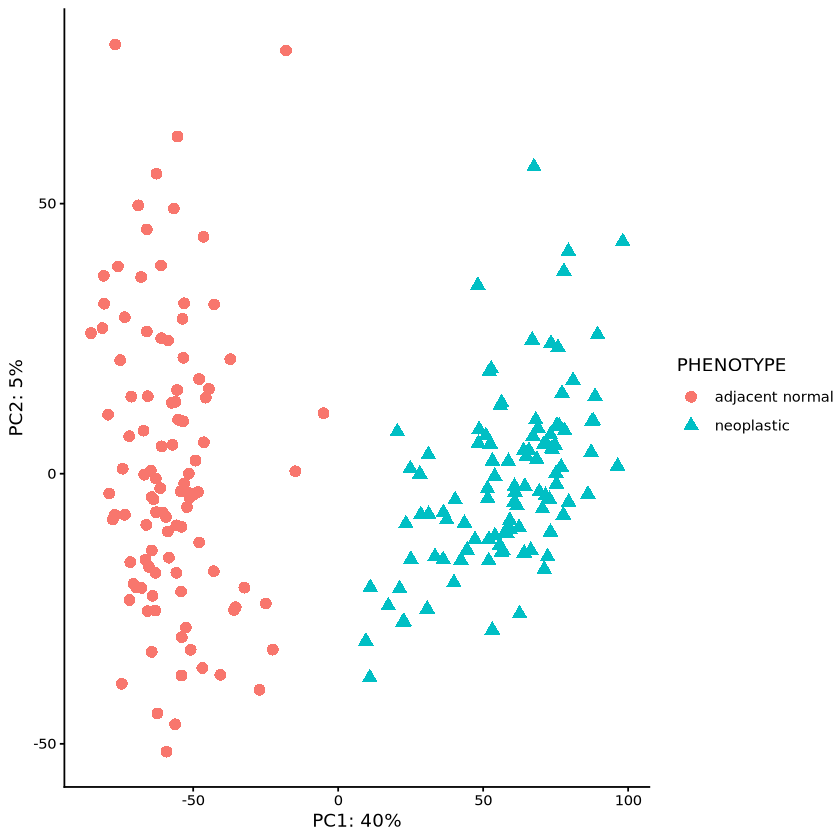

In [134]:
pca_df <- data.frame(
  PC1 = pca$x[,1],
  PC2 = pca$x[,2],
  rna_metadata
)

ggplot(pca_df, aes(PC1, PC2,
                   color = PHENOTYPE,
                   shape = PHENOTYPE)) +
  geom_point(size = 3) +
  xlab(paste0("PC1: ", round(percentVar[1]*100), "%")) +
  ylab(paste0("PC2: ", round(percentVar[2]*100), "%")) +
  theme_classic()

In [135]:
vsd_mirna <- varianceStabilizingTransformation(dds_mirna, blind = TRUE)
pca_mirna <- prcomp(t(assay(vsd_mirna)), scale. = FALSE)
percentVar <- (pca_mirna$sdev^2) / sum(pca_mirna$sdev^2)

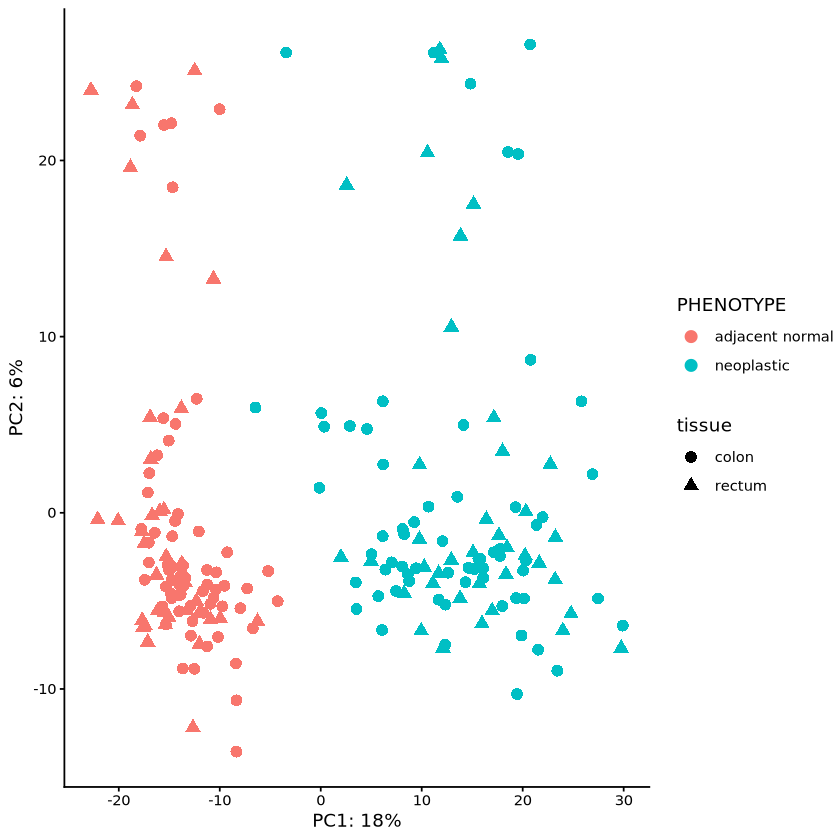

In [136]:
pca_df_mirna <- data.frame(
  PC1 = pca_mirna$x[,1],
  PC2 = pca_mirna$x[,2],
  mirna_metadata
)

ggplot(pca_df_mirna, aes(PC1, PC2,
                   color = PHENOTYPE,
                   shape = tissue)) +
  geom_point(size = 3) +
  xlab(paste0("PC1: ", round(percentVar[1]*100), "%")) +
  ylab(paste0("PC2: ", round(percentVar[2]*100), "%")) +
  theme_classic()

In [137]:
rna_network_dir <- "../rna_pooled"

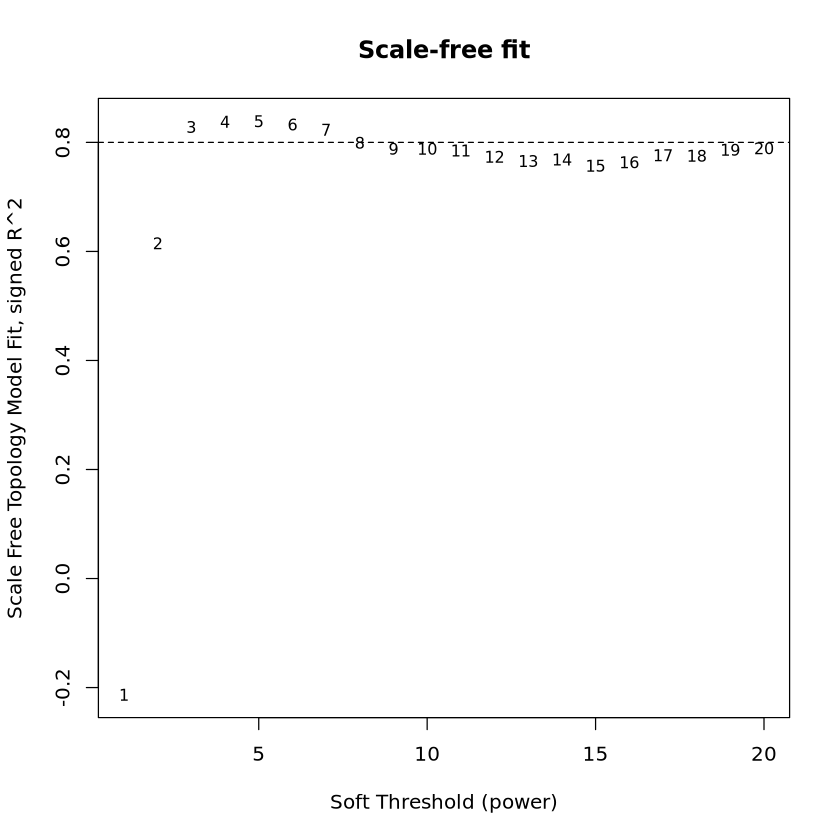

In [138]:
# Load the pre-computed WGCNA modules of RNA pooled
sft <- readRDS(paste(rna_network_dir, "/softThreshold_sft.rds", sep=""))
powers <- sft$fitIndices[,1]
sftR2  <- -sign(sft$fitIndices[,3]) * sft$fitIndices[,2]  # signed R^2

plot(powers, sftR2,
     xlab="Soft Threshold (power)",
     ylab="Scale Free Topology Model Fit, signed R^2",
     type="n", main="Scale-free fit")
text(powers, sftR2, labels=powers, cex=0.8)
abline(h=0.80, lty=2)  # common reference line

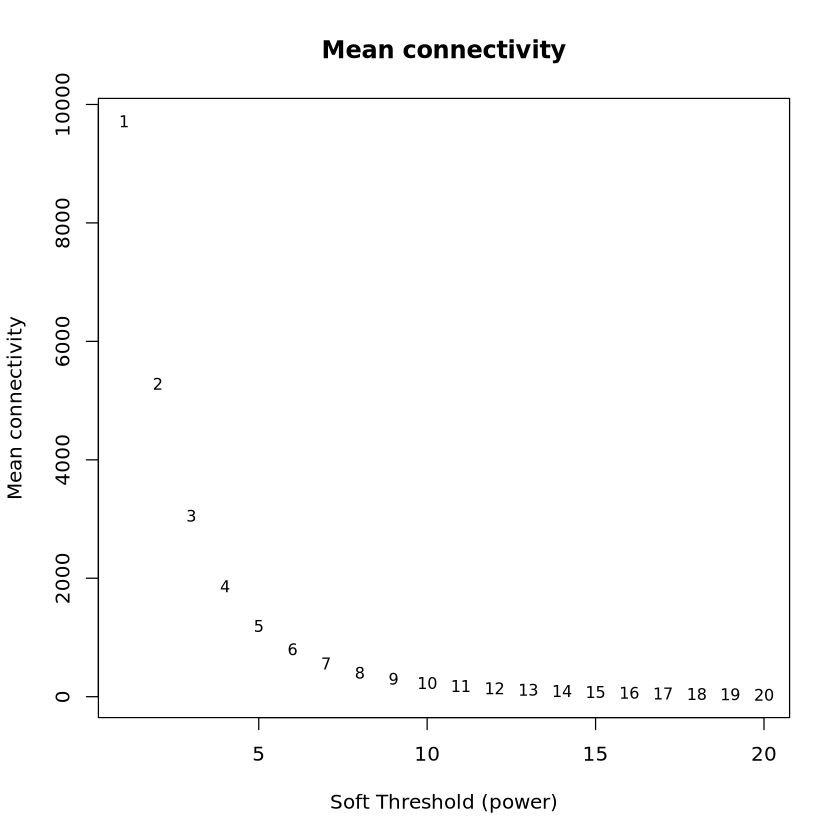

In [139]:
meanK <- sft$fitIndices[,5]  # mean connectivity

plot(powers, meanK,
     xlab="Soft Threshold (power)",
     ylab="Mean connectivity",
     type="n", main="Mean connectivity")
text(powers, meanK, labels=powers, cex=0.8)

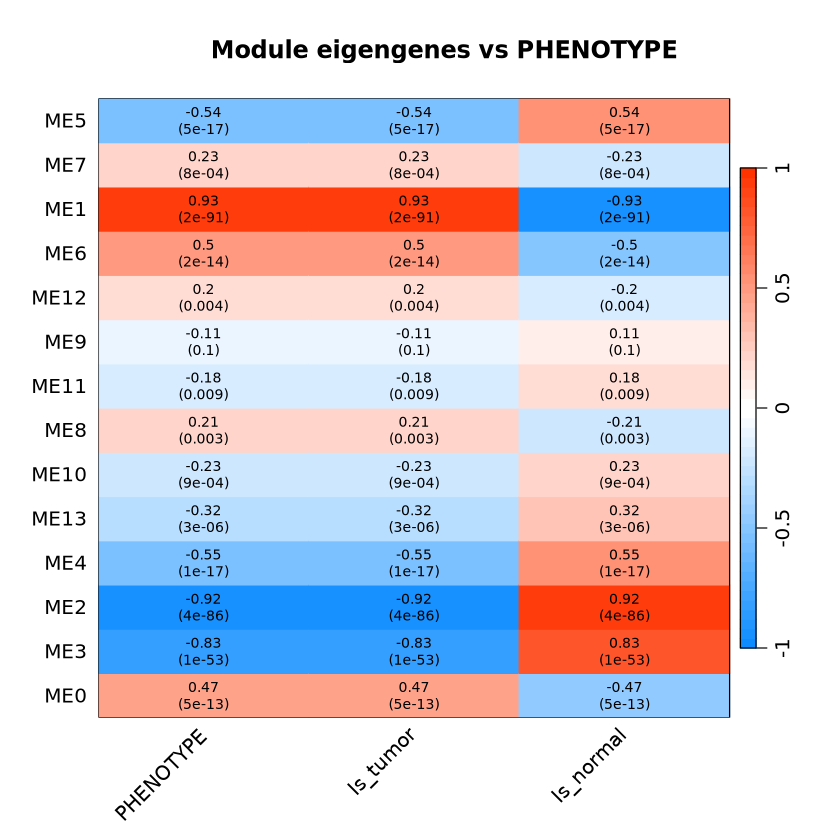

In [140]:
# Load
MEs    <- readRDS(paste(rna_network_dir, "/MEs.rds", sep=""))
traits <- readRDS(paste(rna_network_dir, "/datTraits_clean.rds", sep=""))

# Match samples (same order)
common <- intersect(rownames(MEs), rownames(traits))
MEs    <- MEs[common, , drop = FALSE]
traits <- traits[common, , drop = FALSE]

# Use ONLY PHENOTYPE
if (!("PHENOTYPE" %in% colnames(traits))) stop("Column 'PHENOTYPE' not found in traits.")

trait_pheno <- traits[, "PHENOTYPE", drop = FALSE]

# Convert PHENOTYPE to numeric safely
# Case A: already numeric (0/1)
if (is.numeric(trait_pheno$PHENOTYPE)) {
  # keep as is
} else {
  lev <- unique(as.character(trait_pheno$PHENOTYPE))
  if (length(lev) != 2) {
    stop(paste0(
      "PHENOTYPE must have exactly 2 levels for this heatmap. Found: ",
      paste(sort(lev), collapse = ", ")
    ))
  }
  # Map alphabetically: first level -> 0, second -> 1 (change if you want Tumor=1)
  lev <- sort(lev) # tumor must be 1 and normal must be 0
  trait_pheno$PHENOTYPE <- ifelse(as.character(trait_pheno$PHENOTYPE) == lev[2], 1, 0) # THIS IF FOR TUMOR=1, NORMAL=0
}

# add new columns: Is_tumor and Is_normal
trait_pheno$Is_tumor <- ifelse(trait_pheno$PHENOTYPE == 1, 1, 0)
trait_pheno$Is_normal <- ifelse(trait_pheno$PHENOTYPE == 1, 0, 1)

# Correlations + p-values
MEtraitCor    <- cor(MEs, trait_pheno, use = "p")
MEtraitPvalue <- corPvalueStudent(MEtraitCor, nSamples = nrow(MEs))

# Text matrix
textMatrix <- paste0(signif(MEtraitCor, 2), "\n(", signif(MEtraitPvalue, 1), ")")
dim(textMatrix) <- dim(MEtraitCor)

# Plot
labeledHeatmap(
  Matrix = MEtraitCor,
  xLabels = c("PHENOTYPE", "Is_tumor", "Is_normal"),
  yLabels = colnames(MEs),
  ySymbols = colnames(MEs),
  colorLabels = FALSE,
  colors = blueWhiteRed(50),
  textMatrix = textMatrix,
  setStdMargins = FALSE,
  cex.text = 0.7,
  zlim = c(-1, 1),
  main = "Module eigengenes vs PHENOTYPE"
)

In [141]:
# print heatmap as only values
rna_ME_traitcor <- MEtraitCor
write.csv(MEtraitCor, file = paste(rna_network_dir, "/ME_trait_correlation_values.csv", sep=""))

In [142]:
net <- readRDS(paste(rna_network_dir, "/blockwise_net.rds", sep=""))
rna_net <- net

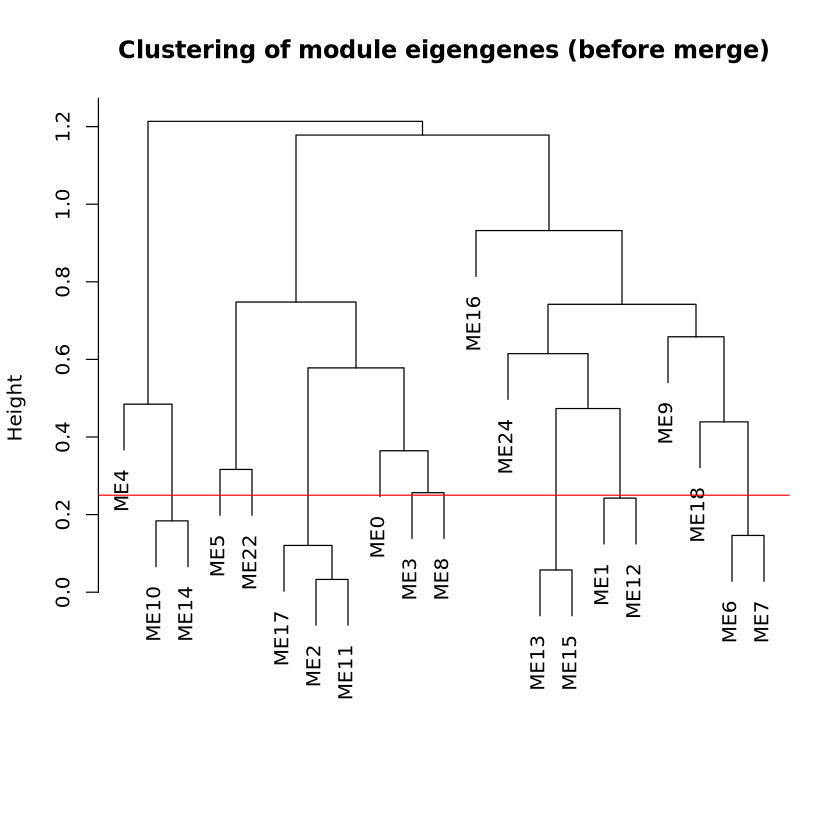

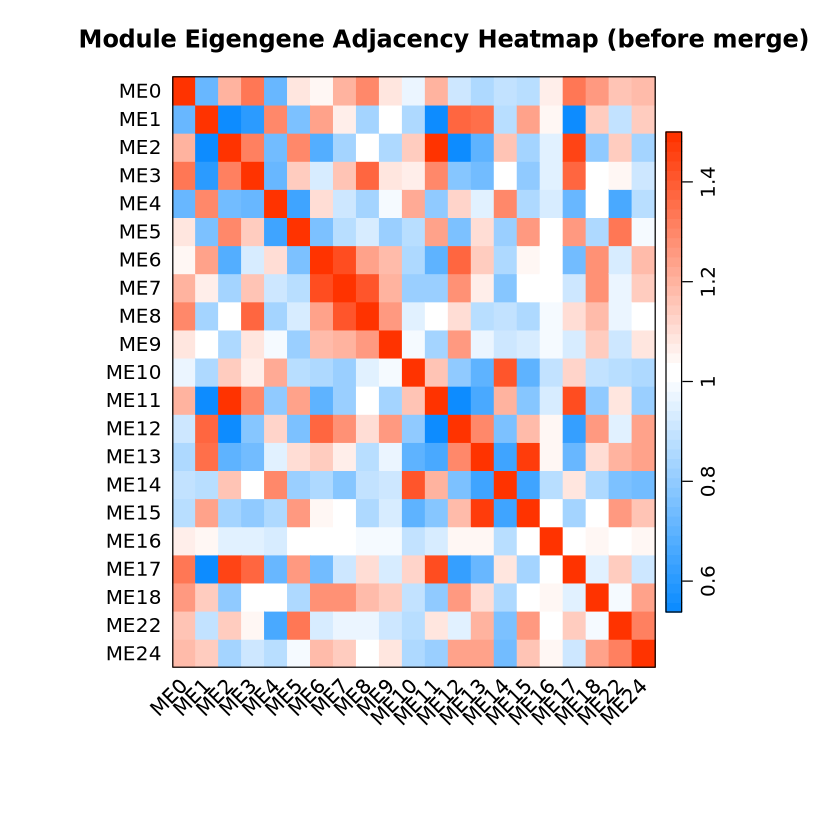

In [143]:
# Visualize the clustering of module eigengenes before merging
datExpr <- readRDS(paste(rna_network_dir, "/datExpr_clean.rds", sep=""))
dynamicColors <- net$unmergedColors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (before merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 abline(h = 0.25, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (before merge)",
               colors = blueWhiteRed(50))

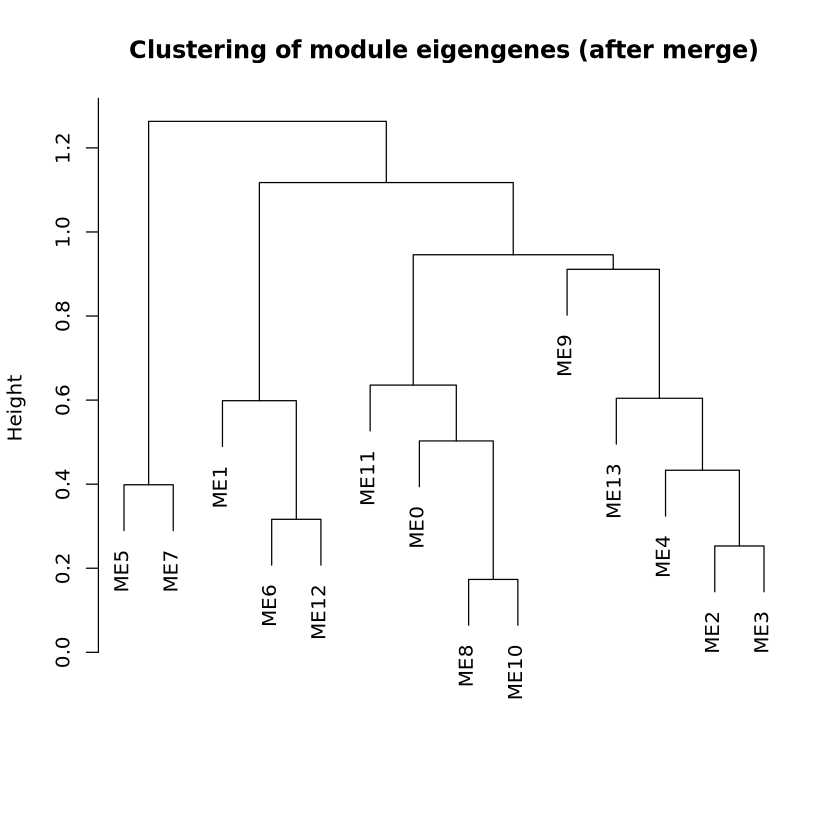

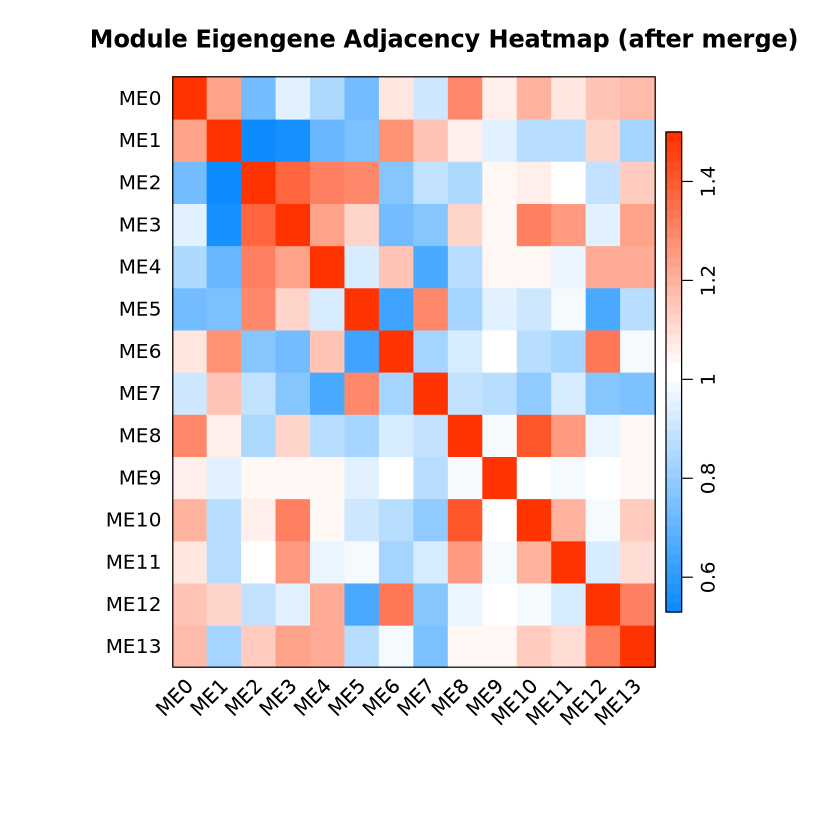

In [144]:
datExpr <- readRDS(paste(rna_network_dir, "/datExpr_clean.rds", sep=""))
dynamicColors <- net$colors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (after merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 #abline(h = 0.45, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (after merge)",
               colors = blueWhiteRed(50))

In [145]:
mirna_network_dir <- "../mirna_pooled"

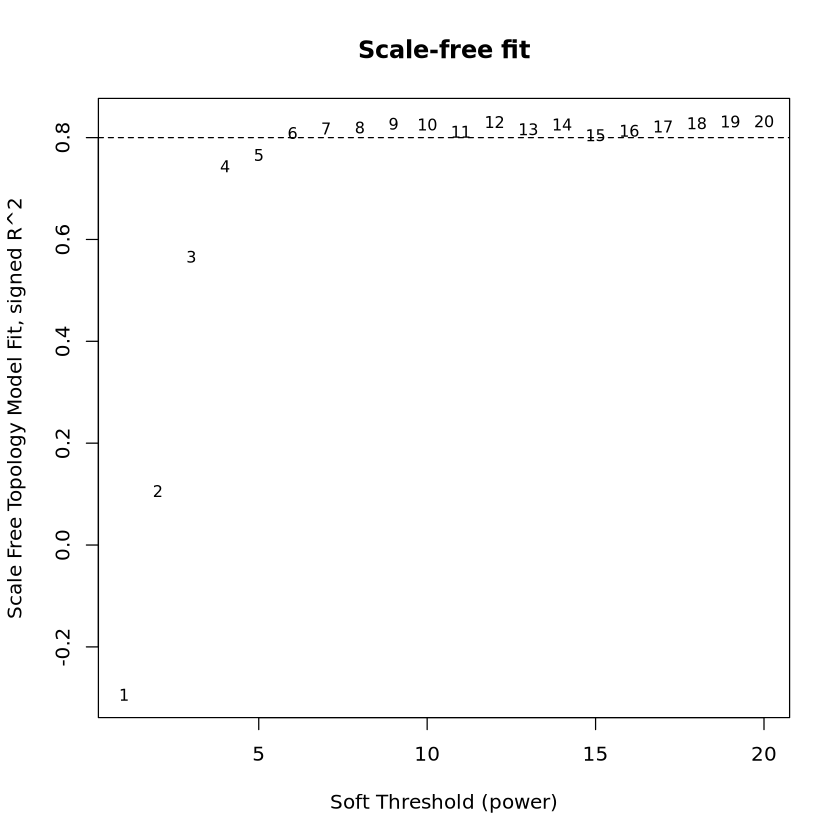

In [146]:
# Load the pre-computed WGCNA modules of miRNA pooled
sft <- readRDS(paste(mirna_network_dir, "/softThreshold_sft.rds", sep=""))
powers <- sft$fitIndices[,1]
sftR2  <- -sign(sft$fitIndices[,3]) * sft$fitIndices[,2]  # signed R^2

plot(powers, sftR2,
     xlab="Soft Threshold (power)",
     ylab="Scale Free Topology Model Fit, signed R^2",
     type="n", main="Scale-free fit")
text(powers, sftR2, labels=powers, cex=0.8)
abline(h=0.80, lty=2)  # common reference line

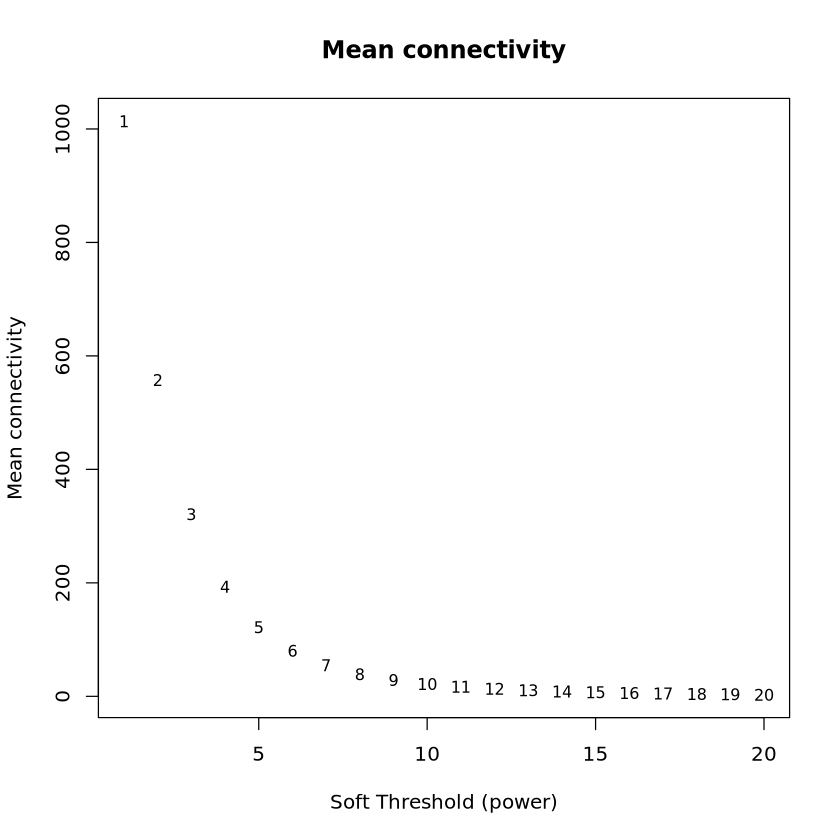

In [147]:
meanK <- sft$fitIndices[,5]  # mean connectivity

plot(powers, meanK,
     xlab="Soft Threshold (power)",
     ylab="Mean connectivity",
     type="n", main="Mean connectivity")
text(powers, meanK, labels=powers, cex=0.8)

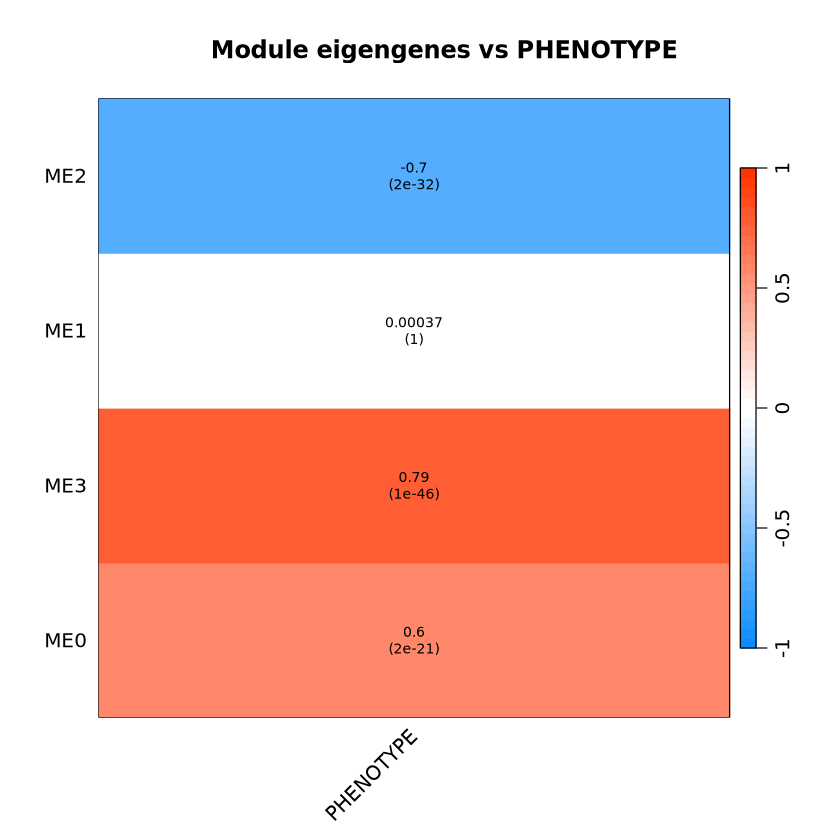

In [148]:
# Load
MEs    <- readRDS(paste(mirna_network_dir, "/MEs.rds", sep=""))
traits <- readRDS(paste(mirna_network_dir, "/datTraits_clean.rds", sep=""))

# Match samples (same order)
common <- intersect(rownames(MEs), rownames(traits))
MEs    <- MEs[common, , drop = FALSE]
traits <- traits[common, , drop = FALSE]

# Use ONLY PHENOTYPE
if (!("PHENOTYPE" %in% colnames(traits))) stop("Column 'PHENOTYPE' not found in traits.")

trait_pheno <- traits[, "PHENOTYPE", drop = FALSE]

# Convert PHENOTYPE to numeric safely
# Case A: already numeric (0/1)
if (is.numeric(trait_pheno$PHENOTYPE)) {
  # keep as is
} else {
  lev <- unique(as.character(trait_pheno$PHENOTYPE))
  if (length(lev) != 2) {
    stop(paste0(
      "PHENOTYPE must have exactly 2 levels for this heatmap. Found: ",
      paste(sort(lev), collapse = ", ")
    ))
  }
  # Map alphabetically: first level -> 0, second -> 1 (change if you want Tumor=1)
  lev <- sort(lev)
  trait_pheno$PHENOTYPE <- ifelse(as.character(trait_pheno$PHENOTYPE) == lev[2], 1, 0)
}

# Correlations + p-values
MEtraitCor    <- cor(MEs, trait_pheno, use = "p")
MEtraitPvalue <- corPvalueStudent(MEtraitCor, nSamples = nrow(MEs))

# Text matrix
textMatrix <- paste0(signif(MEtraitCor, 2), "\n(", signif(MEtraitPvalue, 1), ")")
dim(textMatrix) <- dim(MEtraitCor)

# Plot
labeledHeatmap(
  Matrix = MEtraitCor,
  xLabels = "PHENOTYPE",
  yLabels = colnames(MEs),
  ySymbols = colnames(MEs),
  colorLabels = FALSE,
  colors = blueWhiteRed(50),
  textMatrix = textMatrix,
  setStdMargins = FALSE,
  cex.text = 0.7,
  zlim = c(-1, 1),
  main = "Module eigengenes vs PHENOTYPE"
)

In [149]:
miRNA_traitCor <- MEtraitCor
write.csv(MEtraitCor, file = paste(mirna_network_dir, "/ME_trait_correlation_values.csv", sep=""))

In [150]:
net <- readRDS(paste(mirna_network_dir, "/blockwise_net.rds", sep=""))
mirna_net <- net

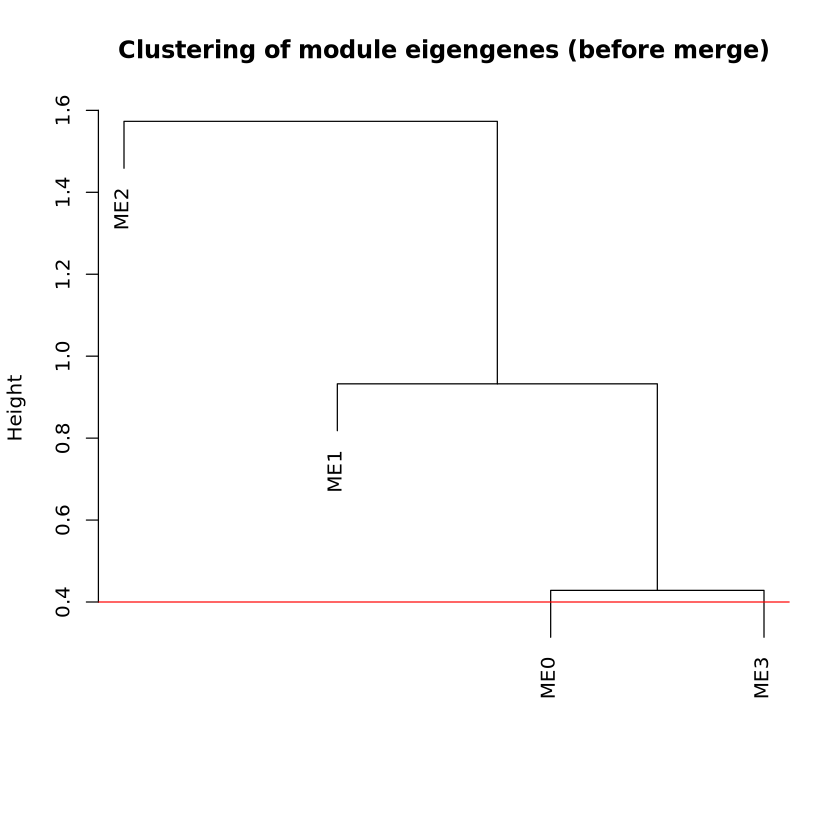

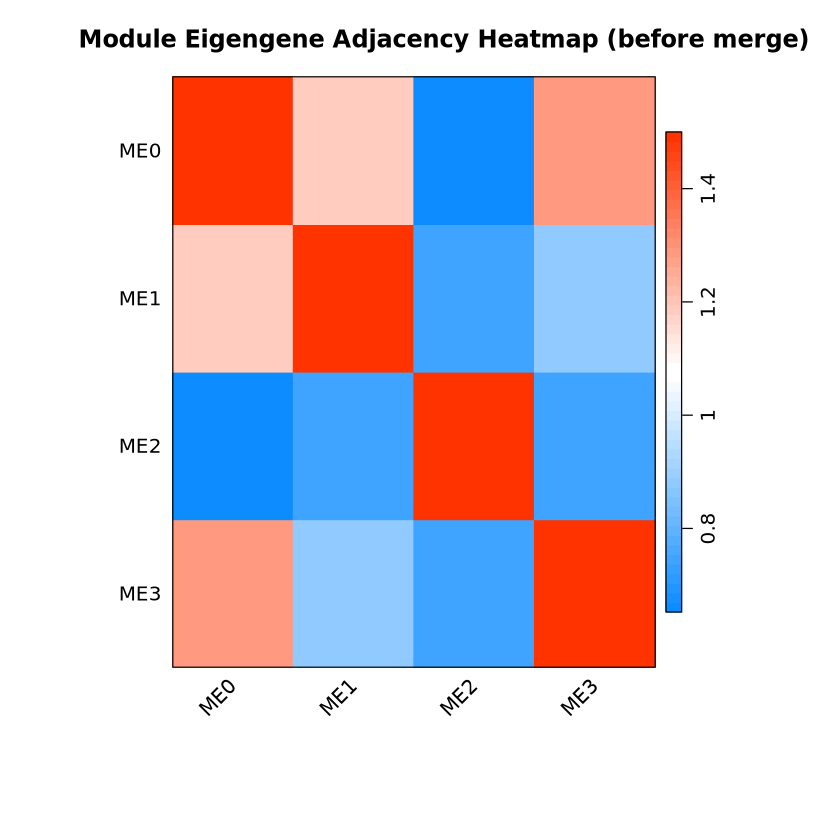

In [151]:
# Visualize the clustering of module eigengenes before merging
datExpr <- readRDS(paste(mirna_network_dir, "/datExpr_clean.rds", sep=""))
dynamicColors <- net$unmergedColors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (before merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 abline(h = 0.4, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (before merge)",
               colors = blueWhiteRed(50))

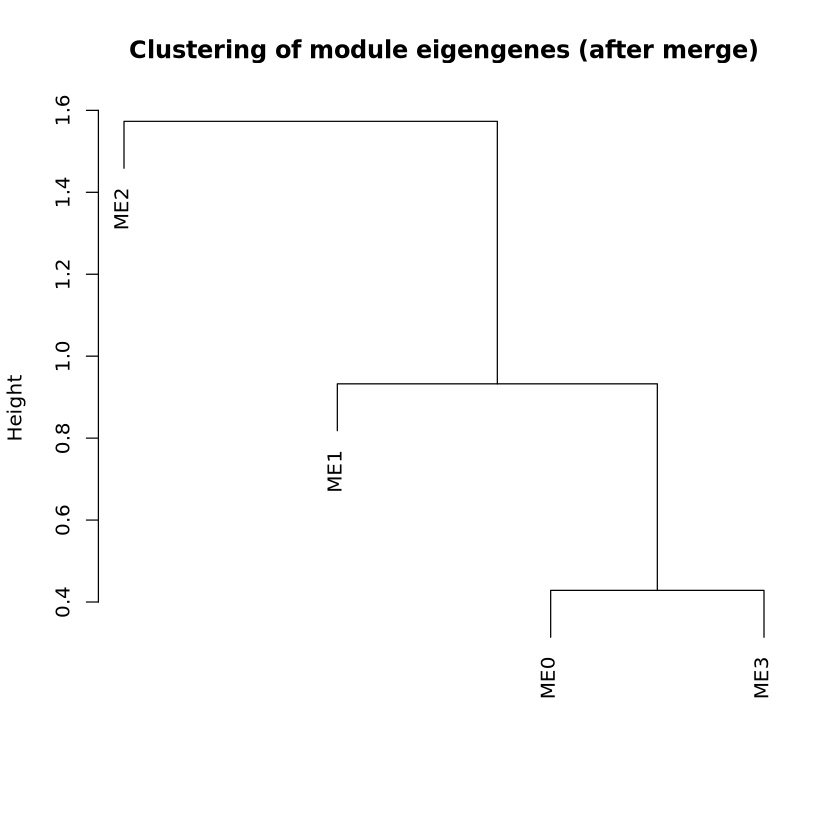

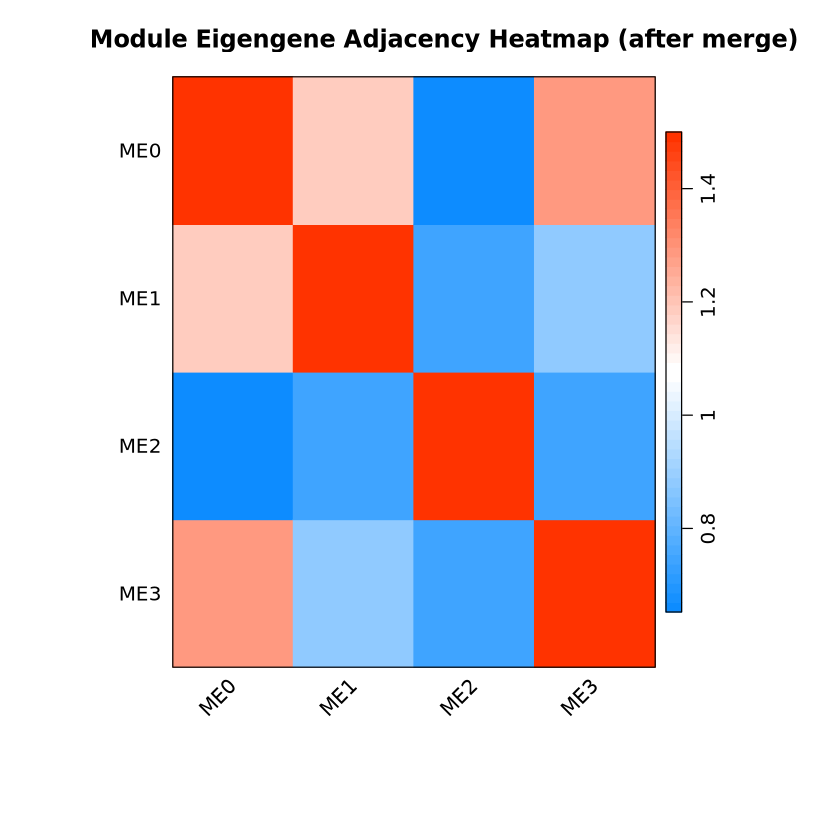

In [152]:
datExpr <- readRDS(paste(mirna_network_dir, "/datExpr_clean.rds", sep=""))
dynamicColors <- net$colors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (after merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 #abline(h = 0.45, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (after merge)",
               colors = blueWhiteRed(50))

In [153]:
MEs_rna <- readRDS(paste(rna_network_dir, "/MEs.rds", sep=""))
MEs_mirna <- readRDS(paste(mirna_network_dir, "/MEs.rds", sep=""))

In [154]:
# get list modules with |r| > 0.4 with PHENOTYPE from miRNA_traitCor and rna_ME_traitcor #miRNA_traitCor #rna_ME_traitcor

MEs_rna <- rna_ME_traitcor[which(abs(rna_ME_traitcor[,1]) > 0.4), , drop=FALSE]
MEs_mirna <- miRNA_traitCor[which(abs(miRNA_traitCor[,1]) > 0.4), , drop=FALSE]

# remove ME0 from MEs_rna and MEs_mirna
MEs_rna <- MEs_rna[!rownames(MEs_rna) %in% "ME0", , drop=FALSE]
MEs_mirna <- MEs_mirna[!rownames(MEs_mirna) %in% "ME0", , drop=FALSE]

# REMOVE ME from the name
rownames(MEs_rna) <- gsub("ME", "", rownames(MEs_rna))
rownames(MEs_mirna) <- gsub("ME", "", rownames(MEs_mirna))

MEs_rna <- as.data.frame(MEs_rna)
MEs_rna$moduleNumber <- rownames(MEs_rna)

MEs_mirna <- as.data.frame(MEs_mirna)
MEs_mirna$moduleNumber <- rownames(MEs_mirna)

In [156]:
datExpr <- readRDS(paste(rna_network_dir, "/datExpr_clean.rds", sep=""))
# open gene module membership table
kme_table <- readRDS(paste(rna_network_dir, "/kME_table.rds", sep=""))
# drop gene column
kme_table <- kme_table[ , -which(names(kme_table) %in% c("gene"))]
nSamples <- nrow(datExpr)
kme_table_P <- corPvalueStudent(as.matrix(kme_table), nSamples = nSamples)

In [157]:
moduleNumbers <- rna_net$colors
unique_map_rna <- unique(data.frame(
  moduleNumber = moduleNumbers,
  moduleColor  = labels2colors(moduleNumbers)))

moduleNumbers <- mirna_net$colors
unique_map_mirna <- unique(data.frame(
  moduleNumber = moduleNumbers,
  moduleColor  = labels2colors(moduleNumbers)))


In [158]:
MEs_rna$moduleColor <- unique_map_rna[match(rownames(MEs_rna), unique_map_rna$moduleNumber), "moduleColor"]
MEs_mirna$moduleColor <- unique_map_mirna[match(rownames(MEs_mirna), unique_map_mirna$moduleNumber), "moduleColor"]

In [159]:
# Load gene mapping to modules
geneModuleMembership_rna <- read.table(paste(rna_network_dir, "/module_membership_gene2module.tsv", sep=""),
                                   sep="\t", header=TRUE, row.names=1)

geneModuleMembership_mirna <- read.table(paste(mirna_network_dir, "/module_membership_gene2module.tsv", sep=""),
                                   sep="\t", header=TRUE, row.names=1)

In [160]:
modules_keep_rna <- MEs_rna$moduleColor
genes_selected_rna <- geneModuleMembership_rna[geneModuleMembership_rna$module %in% modules_keep_rna, , drop=FALSE]

modules_keep_mirna <- MEs_mirna$moduleColor
genes_selected_mirna <- geneModuleMembership_mirna[geneModuleMembership_mirna$module %in% modules_keep_mirna, , drop=FALSE]

genes_selected_rna <- rownames(genes_selected_rna) # has the .XX for the version
genes_selected_mirna <- rownames(genes_selected_mirna) #hsa-miR-XXX-Y

In [ ]:
length(genes_selected_rna)
length(genes_selected_mirna)

[1] 12468

[1] 590

In [ ]:
# load ENCORI dataframe
encori_df <- read_tsv("../../ENCORI_hg38_miRNA-mRNA_ALL_permissive.tsv")

Rows: 627908 Columns: 25
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (9): miRNAid, miRNAname, geneID, geneName, geneType, chromosome, strand...
dbl (16): narrowStart, narrowEnd, broadStart, broadEnd, clipExpNum, degraExp...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
pred_cols <- c(
  "PITA", "RNA22", "miRmap", "microT",
  "miRanda", "PicTar", "TargetScan"
)

In [ ]:
# make a subset of encori_df with:
# clipExpNum >= 1
# OR
# no clipExpNum BUT prediction from at least 3 databases
encori_filtered <- encori_df %>%
  # asegurar que NA cuentan como 0
  mutate(across(all_of(pred_cols), ~ ifelse(is.na(.), 0, .))) %>%
  
  # contar número de predictores activos
  rowwise() %>%
  mutate(n_predicted = sum(c_across(all_of(pred_cols)) > 0)) %>%
  ungroup() %>%
  
  # aplicar la lógica pedida
  filter(
    clipExpNum >= 1 |
    (clipExpNum == 0 & n_predicted >= 3)
  )

In [ ]:
dim(encori_filtered)

[1] 434340     26

In [ ]:
# remove the .XX in the selected_rna genes
genes_selected_rna_noversion <- gsub("\\.\\d+$", "", genes_selected_rna)

In [ ]:
length(unique(encori_filtered$geneID))
length(unique(encori_filtered$miRNAname))

[1] 11873

[1] 205

In [ ]:
new_taiwanese <- miRNAVersionConvert(genes_selected_mirna, targetVersion = "v22", exact=TRUE)

In [ ]:
edges_selected <- encori_filtered %>%
  filter(
    geneID %in% genes_selected_rna_noversion &
    miRNAid %in% genes_selected_mirna
  )

In [ ]:
dim(edges_selected)
write.table(edges_selected, file="ENCORI_filtered_edges_selected_modules_TAIWAN.tsv", sep="\t", quote=FALSE, row.names=FALSE, col.names = TRUE)

[1]  0 26